In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pd.read_csv("archive/Housing.csv")[ [ "price", "area" ] ]
df.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


In [3]:
def standardize(series):
    return (series - series.mean()) / series.std()

df["area_scaled"] = standardize(df["area"])
df["price_scaled"] = standardize(df["price"])

df.head()

,price,area,area_scaled,price_scaled
0,13300000,7420,1.045766,4.562174
1,12250000,8960,1.755397,4.000809
2,12250000,9960,2.216196,4.000809
3,12215000,7500,1.082630,3.982096
4,11410000,7420,1.045766,3.551716


In [4]:
def gradient(x, y, w, b, m):
    # Vectorized gradient calculation
    gw = ((w * x + b - y) * x).sum() / m
    gb = (w * x + b - y).sum() / m
    return gw, gb

def gradientDescent(x, y, w, b, k, a):
    # k: iterations, a: learning rate (alpha)
    m = len(x)
    hist = [(w, b)]
    cost_hist = []
    
    for i in range(k):
        gw, gb = gradient(x, y, w, b, m)
        w -= a * gw
        b -= a * gb
        hist.append((w, b))
        cost_hist.append(cost(x, y, w, b, m))
        
    return hist, cost_hist, w, b

def cost(x, y, w, b, m):
    return ((w * x + b - y) ** 2).sum() / m

In [5]:
# Initial parameters
w = 0
b = 0
a = 0.01
k = 1000
hist, cost_hist, w, b = gradientDescent(df['area_scaled'], df['price_scaled'], w, b, k, a)

In [6]:
print("Model: ")
print("Price = Area * ", w, "+ ", b)

Model: 
Price = Area *  0.5359737732392323 +  2.779591032367966e-16


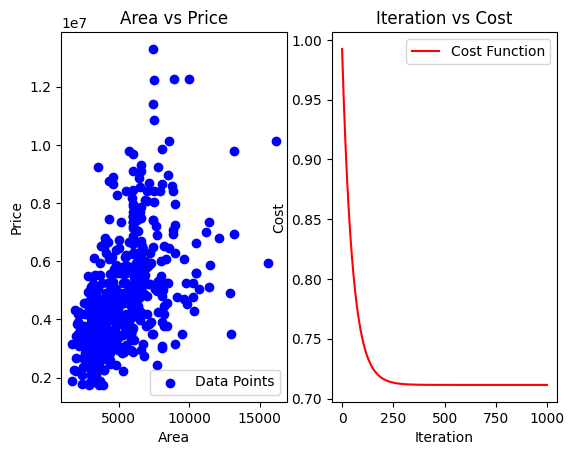

In [7]:
# Plotting
fig, axs = plt.subplots(1, 2)

axs[0].scatter(df['area'], df['price'], color='blue', label='Data Points')
axs[0].set_xlabel('Area')
axs[0].set_ylabel('Price')
axs[0].set_title('Area vs Price')
axs[0].legend()

axs[1].plot(range(k), cost_hist, color='red', label='Cost Function')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Cost')
axs[1].set_title('Iteration vs Cost')
axs[1].legend()

plt.show()